In [ ]:
import time
from ugot import ugot
got=ugot.UGOT()
got.initialize("192.168.1.162")
got.load_models(['face_recognition'])

192.168.1.162:50051


## Register Face

In [ ]:
# Add Bad Guy's face into ugot's face recognition database
got.face_recognition_add_name("Bad Guy")

3 seconds until taking a photo
2 seconds until taking a photo
1 seconds until taking a photo
Taking a photo...
Face [Bad Guy] registered successfully



## Check Camera Feed

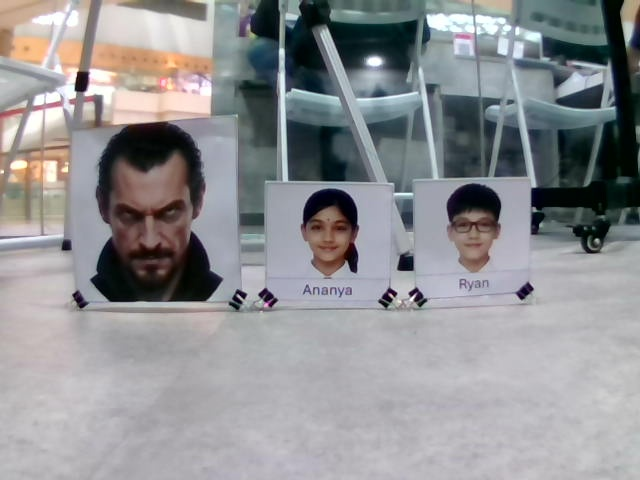

In [ ]:
import cv2
import numpy as np
from IPython.display import display, Image, clear_output

CAMERA_FRAME_WIDTH = 640
CAMERA_FRAME_HEIGHT = 480

got.open_camera()

try:
    while True:
        frame = got.read_camera_data()
        nparr = np.frombuffer(frame, np.uint8)
        img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
        if img is not None:
            # Display in notebook output
            _, jpeg = cv2.imencode('.jpg', img)
            clear_output(wait=True)
            display(Image(data=jpeg.tobytes()))

except KeyboardInterrupt:
    got.mecanum_stop()


Check camera feed for face recognition

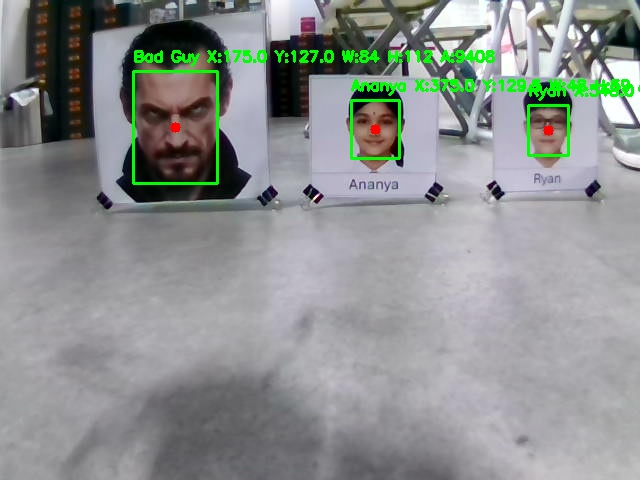

In [ ]:
import cv2
import numpy as np
from IPython.display import display, Image, clear_output

got.open_camera()

try:
    while True:
        # Get detected faces
        # Format:
        # [[name, center_x, center_y, height, width, area], ...]
        faces = got.get_face_recognition_total_info()

        # Read camera frame
        frame = got.read_camera_data()
        nparr = np.frombuffer(frame, np.uint8)
        img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

        if img is None:
            continue

        # Draw bounding boxes for all detected faces
        for face in faces:
            name, center_x, center_y, height, width, area = face

            # Convert center coordinates to rectangle corners
            left = int(center_x - width // 2)
            right = int(center_x + width // 2)
            top = int(center_y - height // 2)
            bottom = int(center_y + height // 2)

            # Draw rectangle
            cv2.rectangle(img, (left, top), (right, bottom), (0, 255, 0), 2)

            # Draw center point
            cv2.circle(img, (int(center_x), int(center_y)), 5, (0, 0, 255), -1)

            # Draw label
            label = (f"{name} "
                f"X:{center_x} "
                f"Y:{center_y} "
                f"W:{width} "
                f"H:{height} "
                f"A:{area}"
            )

            cv2.putText(img, label, (left, top - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

        # Display frame
        _, jpeg = cv2.imencode('.jpg', img)

        clear_output(wait=True)
        display(Image(data=jpeg.tobytes()))

except KeyboardInterrupt:
    got.mecanum_stop()

## Ball Toss

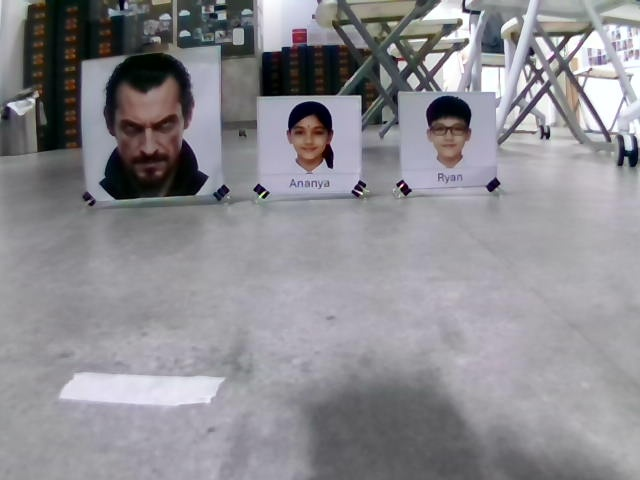

In [ ]:
import cv2
import numpy as np
import time
from IPython.display import display, Image, clear_output

CAMERA_FRAME_WIDTH = 640
CAMERA_FRAME_HEIGHT = 480
LEFT_THRESHOLD = 320 - 10
RIGHT_THRESHOLD = 320 + 10
RED_BALL_PICKUP_THRESHOLD = 200
FACE_WIDTH_APPROACH_THRESHOLD = 80
FACE_WIDTH_APPROACH_TOLERANCE = 10

state = "Ball Search"

RED_HSV_LOWER_1 = np.array([0, 70, 70])
RED_HSV_UPPER_1 = np.array([10, 255, 255])
RED_HSV_LOWER_2 = np.array([170, 70, 70])
RED_HSV_UPPER_2 = np.array([180, 255, 255])

def red_ball_pickup(img, state):
    if state == "Ball Search":
        # Find the red ball in the camera frame
        hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        mask1 = cv2.inRange(hsv_img, RED_HSV_LOWER_1, RED_HSV_UPPER_1)
        mask2 = cv2.inRange(hsv_img, RED_HSV_LOWER_2, RED_HSV_UPPER_2)
        mask = cv2.bitwise_or(mask1, mask2)

        # Find contours of the masked areas
        contours, _ = cv2.findContours(mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
        if contours:
            largest_contour = max(contours, key=cv2.contourArea)
            area = cv2.contourArea(largest_contour)
            if area > 500:  # Minimum area threshold to filter noise
                x, y, w, h = cv2.boundingRect(largest_contour)
                center_x = x + w // 2
                center_y = y + h // 2

                # Draw a rectangle around the detected ball and label it
                cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 255), 2)
                label = f"Center_x: {center_x} Area:{area} w:{w}"
                cv2.putText(img, label, (x, y - 10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 2)

                if w > RED_BALL_PICKUP_THRESHOLD: 
                    got.mecanum_stop()
                    time.sleep(1)
                    got.mechanical_clamp_release()
                    got.mechanical_joint_control(0,-30,-55,1500)
                    time.sleep(2)
                    got.mechanical_clamp_close()
                    time.sleep(1)
                    got.mechanical_joint_control(0,50,80,1500)
                    state = "Search Face"
                elif center_x < LEFT_THRESHOLD:
                    got.mecanum_move_xyz(-5, 0, 0)
                elif center_x > RIGHT_THRESHOLD:
                    got.mecanum_move_xyz(5, 0, 0)
                else:
                    got.mecanum_move_xyz(0, 5, 0)
    return state

got.open_camera()

try:
    # Reset mechanical arm to default position
    got.mechanical_joint_control(0, 50, 80, 1000)
    got.mechanical_clamp_close()

    while True:
        faces = got.get_face_recognition_total_info()
        frame = got.read_camera_data()
        nparr = np.frombuffer(frame, np.uint8)
        img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

        if img is not None:
            if state == "Ball Search":
                state = red_ball_pickup(img, state)
            elif state == "Search Face":
                # If no faces are detected, keep moving forward to search for faces
                if faces == []:
                    got.mecanum_move_xyz(0, 10, 0) 
                else:
                    got.mecanum_stop()
                    state = "Approach Face"
            elif state == "Approach Face":
                for face in faces:
                    name, center_x, center_y, height, width, area = face

                    # Convert center coordinates to box corners
                    left = int(center_x - width // 2)
                    right = int(center_x + width // 2)
                    top = int(center_y - height // 2)
                    bottom = int(center_y + height // 2)

                    cv2.rectangle(img, (left, top), (right, bottom), (0, 255, 0), 2)
                    label = f"{name} Center_x: {center_x} Area:{area}"
                    cv2.putText(img, label, (left, top - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

                    if width < FACE_WIDTH_APPROACH_THRESHOLD - FACE_WIDTH_APPROACH_TOLERANCE:
                        got.mecanum_move_xyz(0, 10, 0)
                    elif width > FACE_WIDTH_APPROACH_THRESHOLD + FACE_WIDTH_APPROACH_TOLERANCE:
                        got.mecanum_move_xyz(0, -10, 0)
                    else:
                        got.mecanum_stop()
                        
                        # Adjust throwing angle
                        if center_x < LEFT_THRESHOLD: # If target is on left side of the frame
                            got.mechanical_joint_control(10, -5, 0, 100) # Adjust arm to the left
                        elif center_x > RIGHT_THRESHOLD: # If target is on right side of the frame
                            got.mechanical_joint_control(-10, -5, 0, 100) # Adjust arm to the right
                        else: # If target is in the center of the frame
                            got.mechanical_joint_control(0, -5, 0, 100) # Adjust arm to the center
                        got.mechanical_clamp_release()
                        got.mecanum_stop()
                        time.sleep(2)
                        state = "Done"
            elif state == "Done":
                got.mecanum_stop()

            # Display in notebook output
            _, jpeg = cv2.imencode('.jpg', img)
            clear_output(wait=True)
            display(Image(data=jpeg.tobytes()))

except KeyboardInterrupt:
    got.mecanum_stop()
